In [15]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.utils.class_weight import compute_class_weight
from google.colab import drive

print('TensorFlow:', tf.__version__)

# Monta o Drive
drive.mount('/content/drive')

TensorFlow: 2.20.0
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [16]:
# ── Configurações ──────────────────────────────────────────────
dataset_path = "/content/drive/MyDrive/Machine learning/Formas"
IMAGE_SIZE   = (224, 224)
BATCH_SIZE   = 32
SEED         = 42

In [17]:
# ── Carrega os dados ───────────────────────────────────────────
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset='training',
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

val_data = tf.keras.preprocessing.image_dataset_from_directory(
    dataset_path,
    validation_split=0.2,
    subset='validation',
    seed=SEED,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE
)

class_names = train_data.class_names
num_classes = len(class_names)
print('Classes:', class_names)
print('Num classes:', num_classes)

Found 144 files belonging to 3 classes.
Using 116 files for training.
Found 144 files belonging to 3 classes.
Using 28 files for validation.
Classes: ['Circulo', 'Quadrado', 'Triangulo']
Num classes: 3


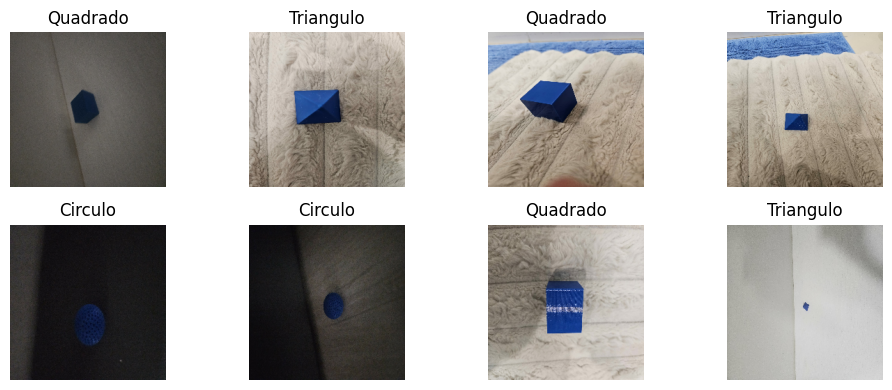

In [18]:
# ── Visualiza algumas amostras ─────────────────────────────────
plt.figure(figsize=(10, 4))
for images, labels in train_data.take(1):
    for i in range(min(8, len(images))):
        ax = plt.subplot(2, 4, i + 1)
        plt.imshow(images[i].numpy().astype('uint8'))
        plt.title(class_names[labels[i]])
        plt.axis('off')
plt.tight_layout()
plt.show()

In [19]:
# ── Class weights (lida com desbalanceamento) ──────────────────
labels_all = np.concatenate([y for x, y in train_data], axis=0)
cw = compute_class_weight('balanced', classes=np.unique(labels_all), y=labels_all)
class_weights = dict(enumerate(cw))
print('Class weights:', class_weights)

Class weights: {0: np.float64(1.0740740740740742), 1: np.float64(0.9206349206349206), 2: np.float64(1.0175438596491229)}


In [20]:
# ── Performance: cache e prefetch ─────────────────────────────
# IMPORTANTE: com dataset pequeno, colocar em cache acelera muito o treino
AUTOTUNE = tf.data.AUTOTUNE
train_data = train_data.cache().shuffle(200).prefetch(buffer_size=AUTOTUNE)
val_data   = val_data.cache().prefetch(buffer_size=AUTOTUNE)

In [21]:
# ── Data Augmentation ─────────────────────────────────────────
# Com ~12 imagens por classe, augmentation é ESSENCIAL
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal_and_vertical'),
    tf.keras.layers.RandomRotation(0.2),          # formas podem estar em qq ângulo
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),  # pequenas translações
    tf.keras.layers.RandomBrightness(0.2),
    tf.keras.layers.RandomContrast(0.15),
], name='augmentation')

In [22]:
# ── Modelo: EfficientNetV2S com transfer learning ──────────────
# EfficientNetV2S supera MobileNetV2 em datasets pequenos

# A EfficientNetV2 já faz a normalização internamente — não precisamos do Rescaling
base_model = tf.keras.applications.EfficientNetV2S(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet'
)

# FASE 1: congela a base toda
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))
x = data_augmentation(inputs)          # augmentation só no treino
x = base_model(x, training=False)      # training=False mantém BatchNorm congelado
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.BatchNormalization()(x)
x = tf.keras.layers.Dropout(0.5)(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)
outputs = tf.keras.layers.Dense(num_classes, activation='softmax')(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ augmentation (Sequential)       │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-s (Functional)   │ (None, 7, 7, 1280)     │    20,331,360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │           387 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 20,500,835 (78.20 MB)

 Trainable params: 166,915 (652.01 KB)

 Non-trainable params: 20,333,920 (77.57 MB)

In [23]:
# ── FASE 1: Treino do topo (base congelada) ────────────────────
print('=== FASE 1: Treinando apenas o topo ===')

callbacks_fase1 = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_accuracy', patience=10, restore_best_weights=True, verbose=1
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1
    )
]

history1 = model.fit(
    train_data,
    validation_data=val_data,
    epochs=40,
    class_weight=class_weights,
    callbacks=callbacks_fase1
)

print(f'Melhor val_accuracy fase 1: {max(history1.history["val_accuracy"]):.2%}')

=== FASE 1: Treinando apenas o topo ===
Epoch 1/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 82s 12s/step - accuracy: 0.4224 - loss: 1.5750 - val_accuracy: 0.6429 - val_loss: 0.9494 - learning_rate: 0.0010
Epoch 2/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 61s 7s/step - accuracy: 0.5690 - loss: 1.0330 - val_accuracy: 0.7500 - val_loss: 0.7917 - learning_rate: 0.0010
Epoch 3/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 29s 7s/step - accuracy: 0.7672 - loss: 0.6659 - val_accuracy: 0.7500 - val_loss: 0.6911 - learning_rate: 0.0010
Epoch 4/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 29s 8s/step - accuracy: 0.7069 - loss: 0.7478 - val_accuracy: 0.7857 - val_loss: 0.6223 - learning_rate: 0.0010
Epoch 5/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 44s 9s/step - accuracy: 0.7069 - loss: 0.7255 - val_accuracy: 0.7857 - val_loss: 0.5762 - learning_rate: 0.0010
Epoch 6/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 29s 8s/step - accuracy: 0.7931 - loss: 0.7186 - val_accuracy: 0.7857 - val_loss: 0.5364 - learning_rate: 0.0010
Epoch 7/40
4/4 ━━━━━━━━━━━━━━━━━━━━ 40s 7s/step - accuracy: 0.7500 - lo

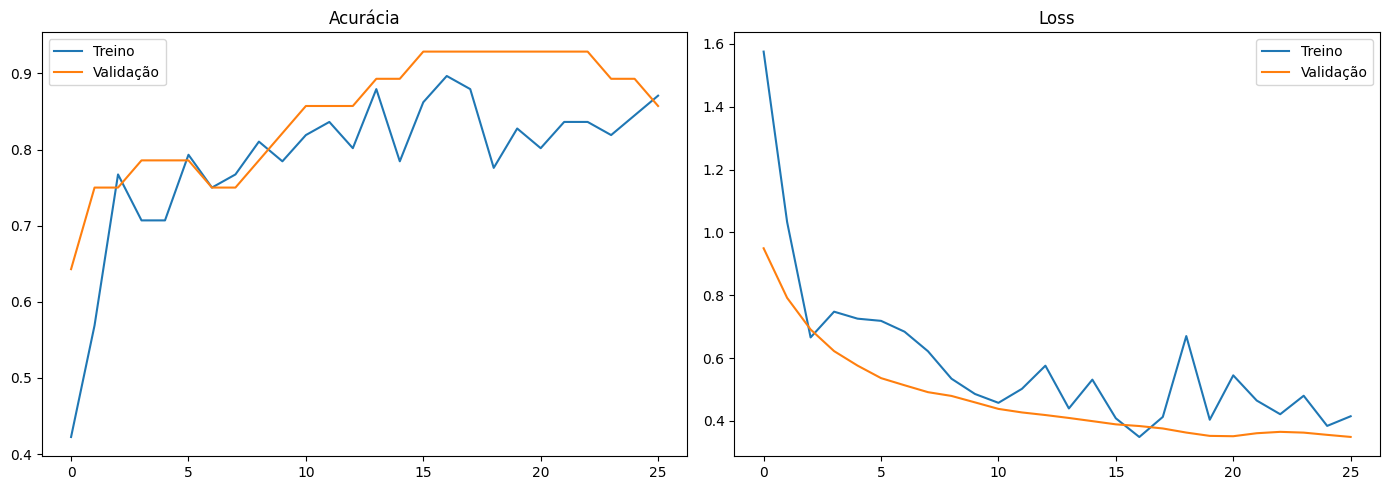

In [24]:
# ── Gráfico de treinamento ─────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history1.history['accuracy'], label='Treino')
ax1.plot(history1.history['val_accuracy'], label='Validação')
ax1.set_title('Acurácia'); ax1.legend()

ax2.plot(history1.history['loss'], label='Treino')
ax2.plot(history1.history['val_loss'], label='Validação')
ax2.set_title('Loss'); ax2.legend()

plt.tight_layout()
plt.show()

In [25]:
# ── Avaliação final ────────────────────────────────────────────
loss, acc = model.evaluate(val_data)
print(f'\nAcurácia final na validação: {acc:.2%}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step - accuracy: 0.9286 - loss: 0.3893

Acurácia final na validação: 92.86%


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step

Probabilidades:
  Circulo: 0.0880
  Quadrado: 0.6615
  Triangulo: 0.2505

Classe prevista: Quadrado (66.15% de confiança)


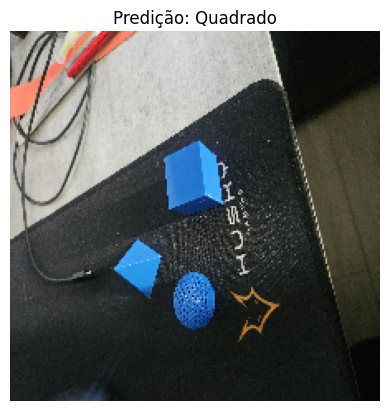

In [28]:
# ── Teste com imagem individual (CORRIGIDO) ────────────────────
IMAGE_PATH = "/content/drive/MyDrive/Machine learning/Formas/20260523_162921.jpg"

img       = tf.keras.preprocessing.image.load_img(IMAGE_PATH, target_size=(224, 224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = tf.expand_dims(img_array, 0)   # (1, 224, 224, 3)
# EfficientNetV2 normaliza internamente — NÃO dividir por 127.5 aqui

prediction = model.predict(img_array)
classe_idx = np.argmax(prediction[0])       # <-- estava faltando no código original

print('\nProbabilidades:')
for i, nome in enumerate(class_names):
    print(f'  {nome}: {prediction[0][i]:.4f}')
print(f'\nClasse prevista: {class_names[classe_idx]} ({prediction[0][classe_idx]:.2%} de confiança)')

plt.imshow(img)
plt.title(f'Predição: {class_names[classe_idx]}')
plt.axis('off')
plt.show()

In [30]:
# ── Salva o modelo ─────────────────────────────────────────────
save_path = '/content/drive/MyDrive/Machine learning/modelo_formas2.keras'
model.save(save_path)
print(f'Modelo salvo em: {save_path}')

Modelo salvo em: /content/drive/MyDrive/Machine learning/modelo_formas2.keras
